# 🛍️ Consumer Shopping Behavior Analysis

## 📌 Project Overview

This project analyzes consumer shopping behavior to identify patterns in customer demographics, purchasing preferences, spending habits, payment methods, subscriptions, and shopping frequency.

The analysis uses Python and Pandas to explore the dataset and generate meaningful insights that can help understand customer behavior.

## 🎯 Objectives

* Analyze customer demographics and purchasing patterns
* Identify popular products and categories
* Understand customer spending behavior
* Analyze payment and shipping preferences
* Explore subscription behavior
* Identify patterns among different customer segments

## 🛠️ Tools & Technologies

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Kaggle
* Jupyter Notebook


# 📊 About the Dataset

The dataset contains **3,900 customer purchase records** and **18 features** related to customer demographics, purchases, product categories, reviews, subscriptions, shipping, discounts, payment methods, and purchase frequency.

### Key Features

* **Customer ID** — Unique customer identifier
* **Age** — Customer age
* **Gender** — Customer gender
* **Item Purchased** — Product purchased
* **Category** — Product category
* **Purchase Amount (USD)** — Amount spent
* **Location** — Customer location
* **Season** — Season of purchase
* **Review Rating** — Customer review rating
* **Subscription Status** — Subscription information
* **Shipping Type** — Shipping method
* **Payment Method** — Payment method
* **Frequency of Purchases** — Purchase frequency


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 📥 Data Loading & Initial Exploration

In [2]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/iamsouravbanerjee/customer-shopping-trends-dataset/shopping_trends_updated.csv")
df.head()
#Load the shopping trends dataset and display the first 5 rows.

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.describe()
# Statistical summary of numerical features

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [4]:
df[(df['Age'] > 20) & (df['Age'] < 25)]
#Filter the dataset to view records for customers between the ages of 21 and 24(young gen)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
20,21,21,Male,Pants,Clothing,51,Louisiana,M,Black,Winter,2.8,Yes,Express,Yes,Yes,50,Cash,Every 3 Months
57,58,21,Male,Coat,Outerwear,64,West Virginia,M,White,Summer,4.4,Yes,Store Pickup,Yes,Yes,17,Debit Card,Fortnightly
70,71,22,Male,Belt,Accessories,29,Alabama,M,Magenta,Fall,4.2,Yes,Express,Yes,Yes,32,Debit Card,Every 3 Months
77,78,22,Male,Dress,Clothing,53,Delaware,L,Gold,Summer,3.3,Yes,Next Day Air,Yes,Yes,36,Debit Card,Fortnightly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3770,3771,23,Female,Pants,Clothing,42,Montana,L,Black,Summer,4.0,No,Store Pickup,No,No,34,Bank Transfer,Weekly
3771,3772,21,Female,T-shirt,Clothing,86,Oklahoma,M,Red,Winter,2.6,No,Express,No,No,28,Venmo,Bi-Weekly
3830,3831,22,Female,Hat,Accessories,27,Pennsylvania,M,Indigo,Summer,3.0,No,2-Day Shipping,No,No,33,Bank Transfer,Every 3 Months
3848,3849,22,Female,Jewelry,Accessories,60,New Hampshire,M,Magenta,Winter,3.0,No,Next Day Air,No,No,39,Cash,Every 3 Months


In [5]:
df[(df["Age"] >= 20) & (df["Age"] <= 25)]["Item Purchased"].value_counts().idxmax()
#What is the most frequently purchased item among customers aged 20 to 25?(young gen)

'Sweater'

In [6]:
df[(df["Age"] >= 20) & (df["Age"] <= 25)]["Item Purchased"].value_counts().idxmin()
#What is the least frequently purchased item among customers aged 20 to 25?(young gen)

'Shoes'

In [7]:
df[(df["Age"] >= 20) & (df["Age"] <= 25)]['Purchase Amount (USD)'].mean()
#What is the average purchase amount (in USD) for customers aged 20 to 25?(young gen)

np.float64(60.688836104513065)

In [8]:
df[df['Gender'] == 'Female']["Item Purchased"].value_counts().idxmax()
#What is the most popular item purchased by female customers?  

'Blouse'

In [9]:
df[df['Gender'] == 'Female']["Item Purchased"].value_counts().idxmin()
#What is the least popular item purchased by female customers?

'Jeans'

In [10]:
df["Location"].value_counts().idxmax()
#Which location (state) has the highest number of customer purchases?

'Montana'

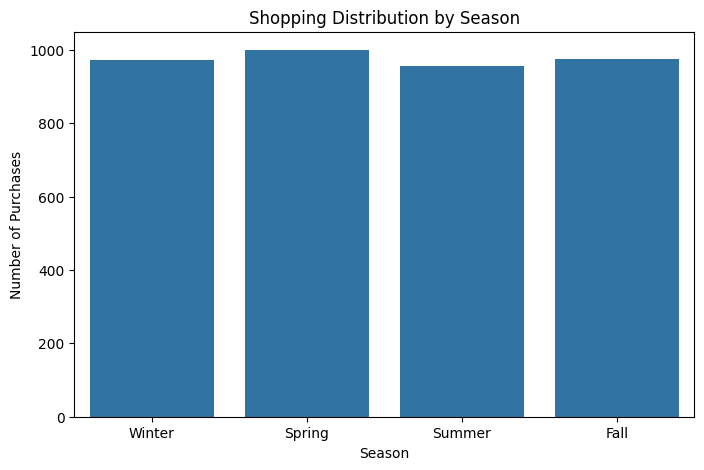

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Season")
plt.title("Shopping Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Number of Purchases")
plt.show()

#Spring has the highest number of purchases among the four seasons in this dataset.

In [12]:
df.groupby("Item Purchased")["Review Rating"].mean().sort_values(ascending=False).head(1)
#Which purchased item has the highest average review rating?  

Item Purchased
Gloves    3.864286
Name: Review Rating, dtype: float64

In [13]:
df["Shipping Type"].value_counts().idxmin()
#What is the least commonly used shipping type?

'2-Day Shipping'

In [14]:
df["Subscription Status"].value_counts()
#How many customers have an active subscription versus no subscription?  

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

In [15]:
df['Previous Purchases'].value_counts().idxmax()
#What is the most frequent number of previous purchases made by a customer?

np.int64(31)

In [16]:
df[(df["Age"] >= 20) & (df["Age"] <= 25)]["Payment Method"].value_counts().idxmax()
#What is the most popular payment method among customers aged 20 to 25?(young gen)

'Cash'

In [17]:
df[df["Age"] > 35]["Payment Method"].value_counts().idxmax()
#What is the most popular payment method among customers older than 35?

'PayPal'

# 📊 Exploratory Data Analysis

This section explores customer demographics, purchasing patterns, spending behavior, and shopping preferences through visualizations.

## 👥 Customer Age Distribution

<Axes: xlabel='Age', ylabel='Count'>

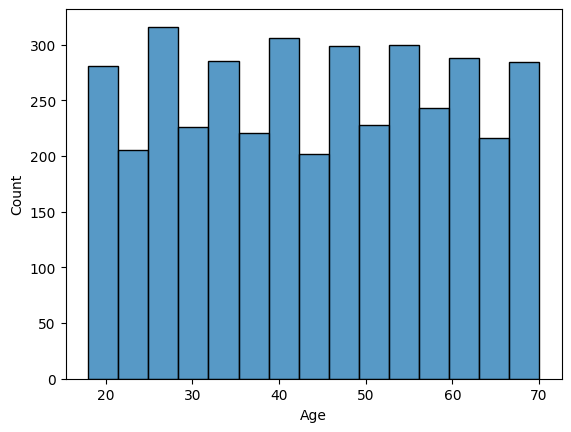

In [20]:
sns.histplot(data=df, x="Age", bins=15)


<Axes: xlabel='Gender', ylabel='count'>

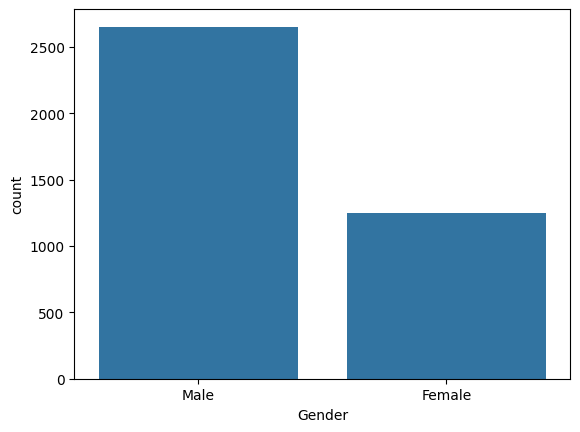

In [21]:
sns.countplot(data=df, x="Gender")

<Axes: xlabel='Category', ylabel='count'>

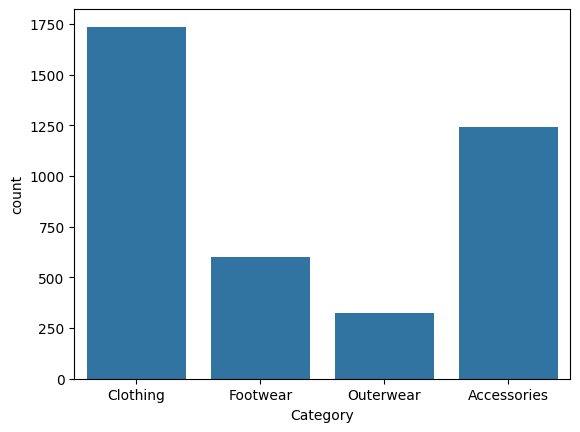

In [22]:
sns.countplot(data=df, x="Category")

<Axes: xlabel='Season', ylabel='count'>

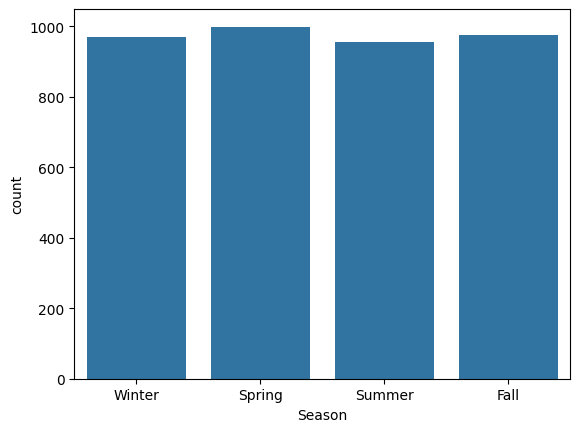

In [23]:
sns.countplot(data=df, x="Season")

<Axes: xlabel='Purchase Amount (USD)', ylabel='Count'>

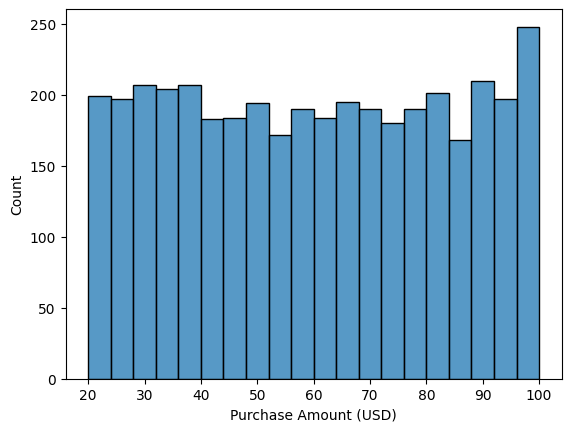

In [24]:
sns.histplot(data=df, x="Purchase Amount (USD)", bins=20)

<Axes: xlabel='Payment Method', ylabel='count'>

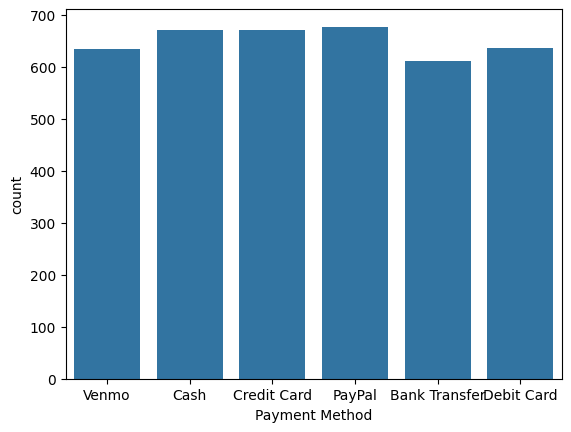

In [25]:
sns.countplot(data=df, x="Payment Method")

<Axes: xlabel='Subscription Status', ylabel='count'>

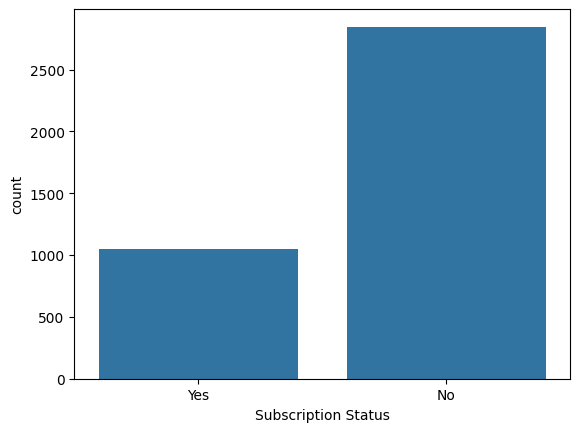

In [26]:
sns.countplot(data=df, x="Subscription Status")

<Axes: xlabel='Category', ylabel='Purchase Amount (USD)'>

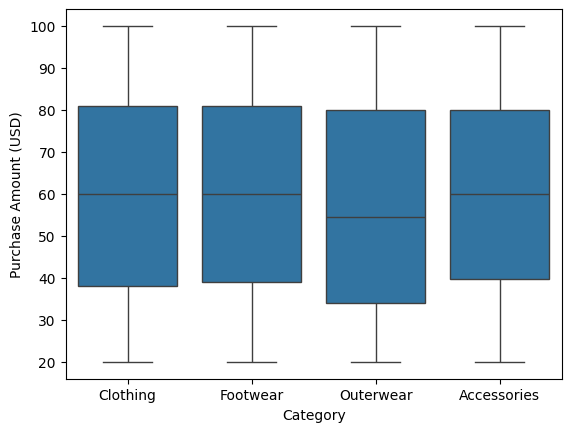

In [27]:
sns.boxplot(data=df, x="Category", y="Purchase Amount (USD)")

# 🏁 Conclusion

This analysis explored consumer shopping behavior across demographic, purchasing, product, payment, shipping, and subscription-related factors.

The analysis identified differences in product preferences across customer groups, variations in purchasing behavior, and patterns in payment, shipping, and subscription choices.

Overall, the project demonstrates how exploratory data analysis can be used to transform raw customer transaction data into meaningful insights that can support better understanding of consumer behavior and business decision-making.
